In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("cell2celltrain.csv")

print(df.shape)
print(df.head())

(51047, 58)
   CustomerID Churn  MonthlyRevenue  MonthlyMinutes  TotalRecurringCharge  \
0     3000002   Yes           24.00           219.0                  22.0   
1     3000010   Yes           16.99            10.0                  17.0   
2     3000014    No           38.00             8.0                  38.0   
3     3000022    No           82.28          1312.0                  75.0   
4     3000026   Yes           17.14             0.0                  17.0   

   DirectorAssistedCalls  OverageMinutes  RoamingCalls  PercChangeMinutes  \
0                   0.25             0.0           0.0             -157.0   
1                   0.00             0.0           0.0               -4.0   
2                   0.00             0.0           0.0               -2.0   
3                   1.24             0.0           0.0              157.0   
4                   0.00             0.0           0.0                0.0   

   PercChangeRevenues  ...  ReferralsMadeBySubscriber  IncomeG

In [3]:
df = df.drop("CustomerID", axis=1)

In [4]:
df = df.fillna(df.median(numeric_only=True))

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

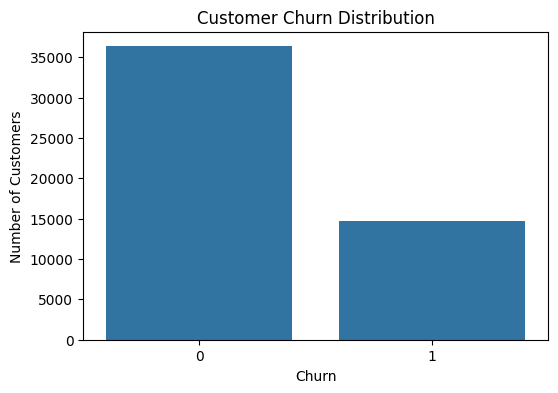

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

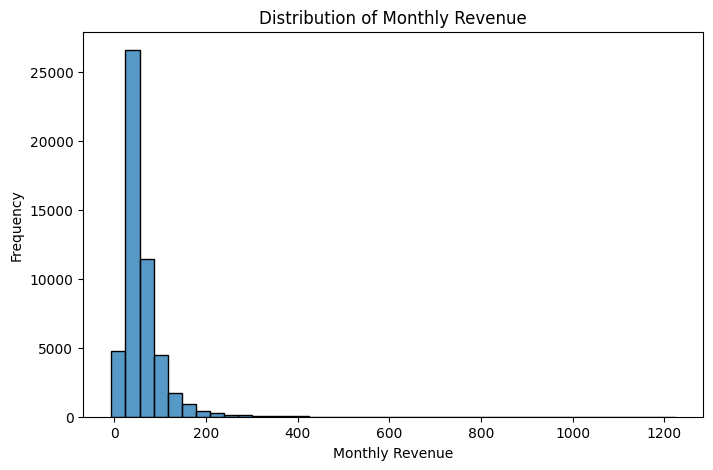

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyRevenue"], bins=40)

plt.title("Distribution of Monthly Revenue")
plt.xlabel("Monthly Revenue")
plt.ylabel("Frequency")

plt.show()

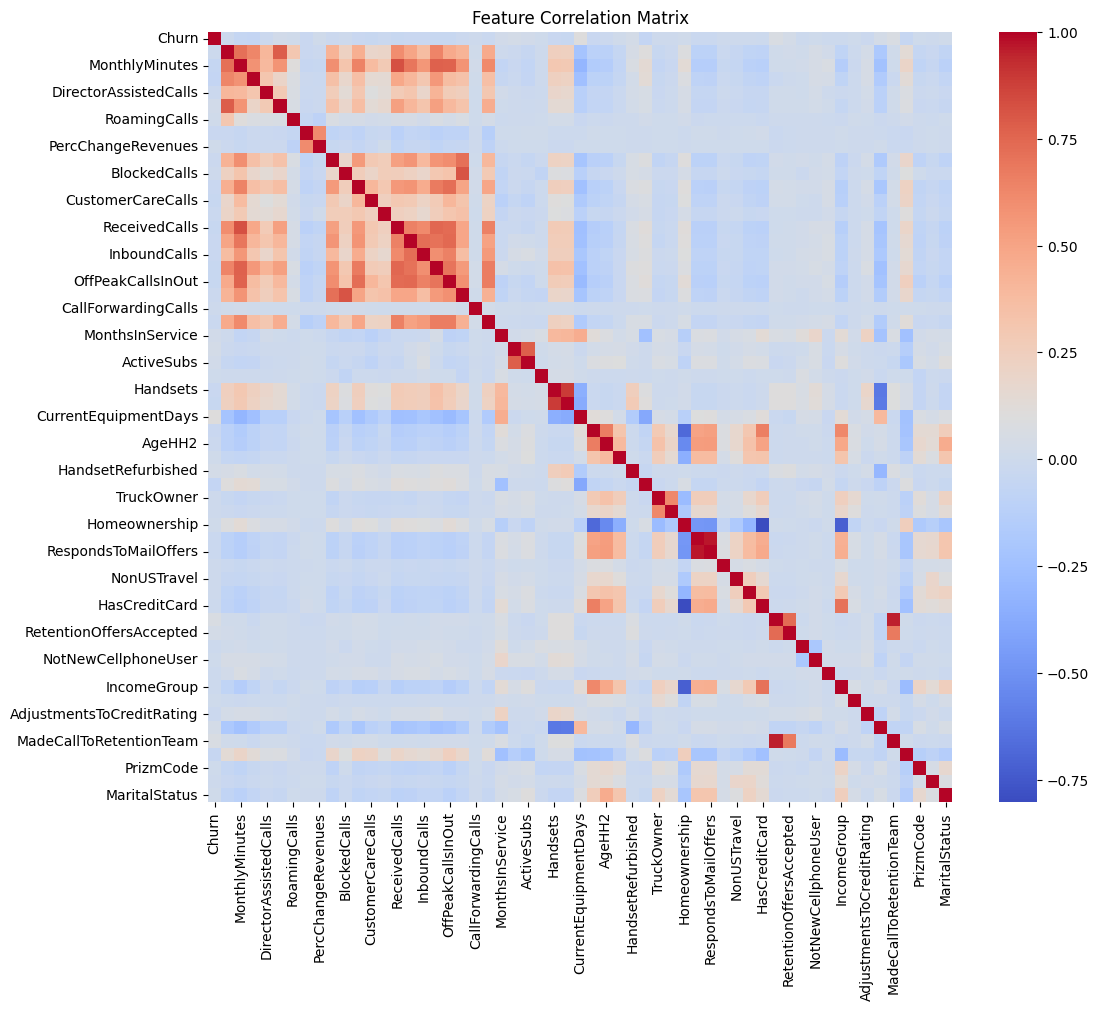

In [11]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6268364348677767


In [15]:
scores = cross_val_score(model, X, y, cv=5)

print("CV scores:", scores)
print("Mean score:", scores.mean())

CV scores: [0.60235064 0.58873653 0.56146537 0.59457342 0.67704966]
Mean score: 0.604835124161633


In [20]:
param_dist = {
    "max_depth": [5, 10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4, 6, 10],
    "criterion": ["gini", "entropy", "log_loss"]
}

In [21]:
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,n_iter,25
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
best_model = random_search.best_estimator_

pred = best_model.predict(X_test)

print("Best params:", random_search.best_params_)
print("Final accuracy:", accuracy_score(y_test, pred))

Best params: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5, 'criterion': 'entropy'}
Final accuracy: 0.7202742409402546


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.72      0.98      0.83      7308
           1       0.58      0.06      0.10      2902

    accuracy                           0.72     10210
   macro avg       0.65      0.52      0.47     10210
weighted avg       0.68      0.72      0.63     10210

